# Exercise 12: image recognition

**The goal of exercise 12 is to use deep neural network models, implemented in the Keras python package, to recognize and distinguish between the ten handwritten digits (0-9).**



In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

import utils
seed=0
np.random.seed(seed) # fix random seed
tf.random.set_seed(seed)

## 12.1
**Change at will and train your DNN by increasing the number of epochs to an adequate value. Try to use at least two other optimizers, different from SGD: watch to accuracy and loss for training and validation data and comment on the performances.**

First I test with few epochs the most convenient optimizer (if it's better with few epochs it's going to be better with more?). The model I am using is a sequential NN with the following architecture:

In [2]:
# input image dimensions
img_rows, img_cols = 28, 28 # number of pixels 
# output
num_classes = 10 # 10 digits

In [7]:
    model = Sequential()
    # add a dense all-to-all relu layer
    model.add(layers.Dense(400,input_shape=(img_rows*img_cols,), activation='relu'))
    # add a dense all-to-all relu layer
    model.add(layers.Dense(100, activation='relu'))
    # apply dropout with rate 0.5
    model.add(layers.Dropout(0.5))
    # soft-max layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.summary()

/home/elisa/miniconda3/envs/thesis/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,110 (1.35 MB)

 Trainable params: 355,110 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
optimizers_to_test = ["sgd","adam","nadam", "adamax","rmsprop"]
histories = []
times=[]
predictions = []
batch_size = 32
epochs = 10
for opt in optimizers_to_test:
    X_train,Y_train,X_test,Y_test,input_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes)
    time,hist,pred = utils.test_DNN(img_rows,img_cols,num_classes,X_train,Y_train,X_test,Y_test,batch_size,epochs,opt,return_pred=True)
    histories.append(hist)
    times.append(time)
    predictions.append(pred)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.6365 - loss: 1.1786 - val_acc: 0.9093 - val_loss: 0.3205
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.8806 - loss: 0.4174 - val_acc: 0.9290 - val_loss: 0.2464
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - acc: 0.9072 - loss: 0.3276 - val_acc: 0.9372 - val_loss: 0.2091
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - acc: 0.9206 - loss: 0.2813 - val_acc: 0.9435 - val_loss: 0.1837
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - acc: 0.9317 - loss: 0.2489 - val_acc: 0.9495 - val_loss: 0.1668
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - acc: 0.9371 - loss: 0.2242 - val_acc: 0.9532 - val_loss: 0.1523
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - acc: 0.9428 - loss: 0.2019 - val_acc: 0.9585 - val_loss: 0.1379
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - acc: 0.9464 - loss: 0.1868 - val_acc: 0.9609 - val_loss: 0.1276
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━

In [10]:
for i,t in enumerate(times):
    print(f'Optimizer {optimizers_to_test[i]} took {t} seconds')

Optimizer sgd took 91.7876787185669 seconds
Optimizer adam took 147.3439564704895 seconds
Optimizer nadam took 155.77567982673645 seconds
Optimizer adamax took 155.0647406578064 seconds
Optimizer rmsprop took 134.12365651130676 seconds


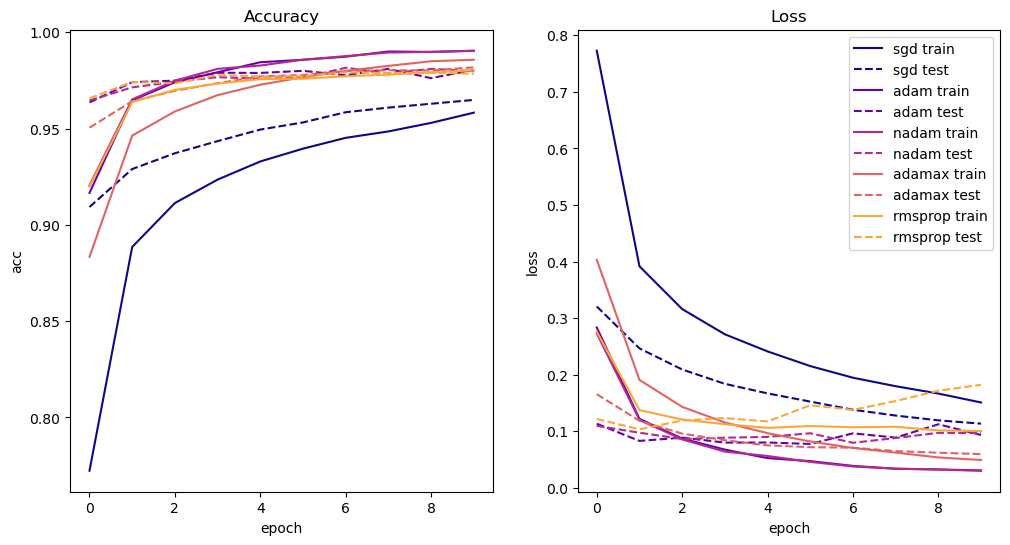

In [11]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, len(histories)+1))
ax[0].set_title ("Accuracy")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("acc")
ax[1].set_title("Loss")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("loss")
for i in range(len(histories)):
    ax[0].plot(histories[i].history["acc"],label = f'{optimizers_to_test[i]} train',c = colors[i])
    ax[0].plot(histories[i].history["val_acc"],label = f'{optimizers_to_test[i]} test',c = colors[i],linestyle = 'dashed')

        
    ax[1].plot(histories[i].history["loss"],label = f'{optimizers_to_test[i]} train',c = colors[i])
    ax[1].plot(histories[i].history["val_loss"],label = f'{optimizers_to_test[i]} test',c = colors[i],linestyle = 'dashed')

plt.legend()
plt.show()

conclusions:
- at first glance best result might be from adam/nadam, but test loss is stagnating: might be overfitting?
- meanwhule adamax looks to be continuously decreasing
- rmsprop is definitely overfitting
- nadam has much longer computation time, so test adam and adamax with a larger number of epochs

In [37]:
epochs = 20
times,histories,predictions,X_test_list,Y_test_list = [],[],[],[],[]

optimizers_to_test = ['sgd','adamax']

for opt in optimizers_to_test:
    X_train,Y_train,X_test,Y_test,input_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes)
    time,hist,pred = utils.test_DNN(img_rows,img_cols,num_classes,X_train,Y_train,X_test,Y_test,batch_size,epochs,opt,return_pred=True)
    histories.append(hist)
    times.append(time)
    predictions.append(pred)
    X_test_list.append(X_test)
    Y_test_list.append(Y_test)
    eps = np.linspace(1,epochs,epochs)
    with open(f"./OUTPUT/{opt}_DNN_test.csv","w") as out:
        out.write("epoch\tloss\tval_loss\tacc\tval_acc\n")
        for i in range(len(hist.history['loss'])):
            out.write(f"{eps[i]}\t{hist.history['loss'][i]}\t{hist.history['val_loss'][i]}\t{hist.history['acc'][i]}\t{hist.history['val_acc'][i]}\n")

/home/elisa/miniconda3/envs/thesis/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.6401 - loss: 1.1641 - val_acc: 0.9135 - val_loss: 0.3134
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.8809 - loss: 0.4141 - val_acc: 0.9287 - val_loss: 0.2423
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9075 - loss: 0.3286 - val_acc: 0.9399 - val_loss: 0.2052
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9206 - loss: 0.2763 - val_acc: 0.9474 - val_loss: 0.1764
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9311 - loss: 0.2424 - val_acc: 0.9526 - val_loss: 0.1599
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - acc: 0.9387 - loss: 0.2191 - val_acc: 0.9567 - val_loss: 0.1440
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - acc: 0.9443 - loss: 0.1990 - val_acc: 0.9594 - val_loss: 0.1330
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.9482 - loss: 0.1844 - val_acc: 0.9619 - val_loss: 0.1238
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━

computation times:


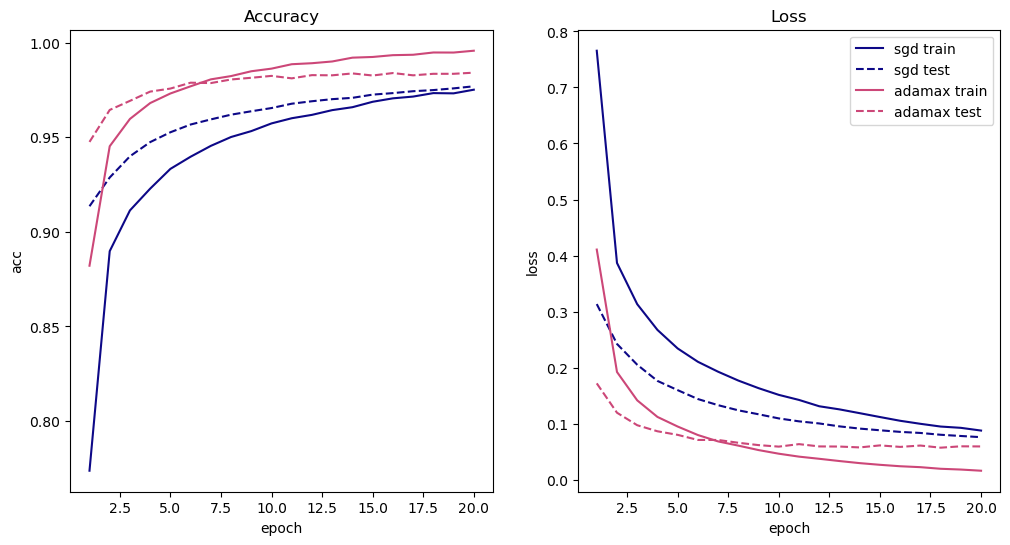

In [38]:

fig,ax = plt.subplots(1,2,figsize=(12,6))
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, 3))
ax[0].set_title ("Accuracy")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("acc")
ax[1].set_title("Loss")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("loss")
print('computation times:')
#print(times)
#for i,t in enumerate(times):
    #print(f'{optimizers_to_test[i]} took {t} seconds')

for i in range(len(histories)):

    df = pd.read_csv(f"./OUTPUT/{optimizers_to_test[i]}_DNN_test.csv",sep = '\t')
    ax[0].plot(df['epoch'],df["acc"],label = f'{optimizers_to_test[i]} train',c = colors[i])
    ax[0].plot(df['epoch'],df["val_acc"],label = f'{optimizers_to_test[i]} test',c = colors[i],linestyle = 'dashed')

        
    ax[1].plot(df['epoch'],df["loss"],label = f'{optimizers_to_test[i]} train',c = colors[i])
    ax[1].plot(df['epoch'],df["val_loss"],label = f'{optimizers_to_test[i]} test',c = colors[i],linestyle = 'dashed')

plt.legend()
plt.show()

adam test loss increases a lot: sign of overfitting?
probably adamax is a better choice even though it converges less rapidly

In [ ]:
for j in range(len(predictions)):

    X_test = X_test_list[j].reshape(X_test_list[j].shape[0], img_rows, img_cols,1)

    plt.figure(figsize=(15, 15)) 
    for i in range(10):    
        ax = plt.subplot(2, 10, i + 1)    
        plt.imshow(X_test[i, :, :, 0], cmap='gray')    
        plt.title("Digit: {}\nPredicted:    {}".format(np.argmax(Y_test[j]), np.argmax(predictions[j])))    
        plt.axis('off') 
    plt.show()

adamax seems more stable

## 12.2

**Change the architecture of your DNN using convolutional layers. Use `Conv2D`, `MaxPooling2D`, `Dropout`, but also do not forget `Flatten`, a standard `Dense` layer and `soft-max` in the end.**

try 3 models:
- a simple one with just one convolution and one max pooling
- intermediate one with 2 conv, 2 max pooling and dropout
- most complex with additional dense layer and intermediate dropout

In [20]:
#model 1
from keras import layers
models = []
X_train,Y_train,X_test,Y_test,input_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes,NNtype='CNN')

model = Sequential(
    [
        layers.Input(shape=input_shape),
        layers.Conv2D(10, kernel_size=(5,5), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2),padding='valid'),
        #layers.Dropout(0.5),
        layers.Conv2D(16, kernel_size=(5,5), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2),strides=1,padding='valid'),
        layers.Flatten(),
        layers.Dense(100,activation="relu"),
        
        layers.Dense(num_classes, activation="softmax"),
    ]
)
model.summary()
model.compile(loss=keras.losses.categorical_crossentropy,
                optimizer='Adamax',metrics=['accuracy'])



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 16)       │         4,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,786 (327.29 KB)

 Trainable params: 83,786 (327.29 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:

epochs=20
batch_size=32  
import time

t0=time.time()
X_train,Y_train,X_test,Y_test,input_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes,NNtype='CNN')

model.compile(loss=keras.losses.categorical_crossentropy,
            optimizer='Adamax',metrics=['acc'])

hist = model.fit(X_train, Y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, Y_test))
t1=time.time()
histories.append(hist)
eps = np.linspace(0,epochs-1,epochs)
print(model.metrics_names)


score= model.evaluate(X_test, Y_test,verbose=1)
score= model.evaluate(X_test, Y_test)
print(f'time\t{t1-t0}')
print(f'test loss:\t{score[0]}')
print(f'test accuracy:\t{score[1]}')
model.save('./OUTPUT/model_CNN.keras') 

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - acc: 0.8082 - loss: 3.1089 - val_acc: 0.9529 - val_loss: 0.1898
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - acc: 0.9536 - loss: 0.1888 - val_acc: 0.9708 - val_loss: 0.1132
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - acc: 0.9742 - loss: 0.0980 - val_acc: 0.9774 - val_loss: 0.0902
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - acc: 0.9834 - loss: 0.0614 - val_acc: 0.9795 - val_loss: 0.0777
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - acc: 0.9889 - loss: 0.0405 - val_acc: 0.9809 - val_loss: 0.0796
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - acc: 0.9915 - loss: 0.0276 - val_acc: 0.9822 - val_loss: 0.0800
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - acc: 0.9934 - loss: 0.0195 - val_acc: 0.9813 - val_loss: 0.0798
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - acc: 0.9955 - loss: 0.0139 - val_acc: 0.9816 - val_loss: 0.0802
Epoch 9/20
1875/1875 ━━━

The final accuracies for the 3 tested CNNs are, in order, around 97%,98% and 99%, which are already very good for only 5 epochs. From the plots above we can see that whilethere is a significant improvement between the simplest architecture and the other two, the difference between the latter is not as important. For this reason I am choosing model 2 as my CNN architecture, since model3 takes double the time and only improves the performance a little, which wouldn't be significant anyway for a higher number of epochs

Text(0.5, 1.0, 'Accuracy')

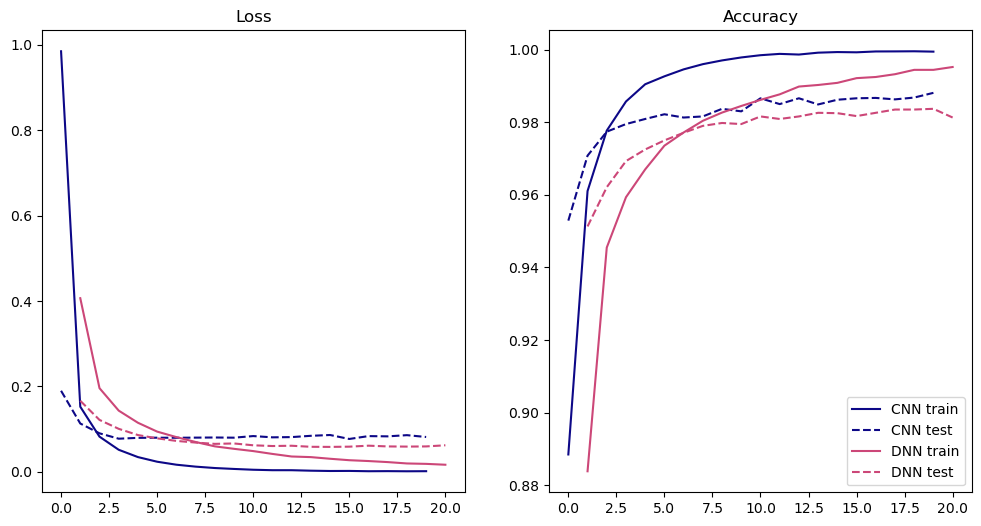

In [29]:
#comparison with DNN
dnn_df = pd.read_csv("./OUTPUT/adamax_DNN_test.csv",sep='\t')
fig,ax = plt.subplots(1,2,figsize=(12,6))
cmap = plt.colormaps['plasma']
colors = cmap(np.linspace(0, 1, 3))

ax[0].plot(hist.history['loss'],c=colors[0],label = 'CNN train')
ax[0].plot(hist.history['val_loss'],c=colors[0],linestyle='dashed',label = 'CNN test')
ax[0].plot(dnn_df['epoch'][:20],dnn_df['loss'][:20],c=colors[1],label = 'DNN train')
ax[0].plot(dnn_df['epoch'][:20],dnn_df['val_loss'][:20],c=colors[1],linestyle='dashed',label = 'DNN test')

ax[1].plot(hist.history['acc'],c=colors[0],label = 'CNN train')
ax[1].plot(hist.history['val_acc'],c=colors[0],linestyle='dashed',label = 'CNN test')
ax[1].plot(dnn_df['epoch'][:20],dnn_df['acc'][:20],c=colors[1],label = 'DNN train')
ax[1].plot(dnn_df['epoch'][:20],dnn_df['val_acc'][:20],c=colors[1],linestyle='dashed',label = 'DNN test')
plt.legend()
ax[0].set_title('Loss')
ax[1].set_title('Accuracy')

CNN convergennce is faster and test loss/accuracy is better

In [46]:
DNN_model = tf.keras.models.load_model(
    "./OUTPUT/DNN_test_adamax_20.keras", custom_objects=None, compile=True, safe_mode=True)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


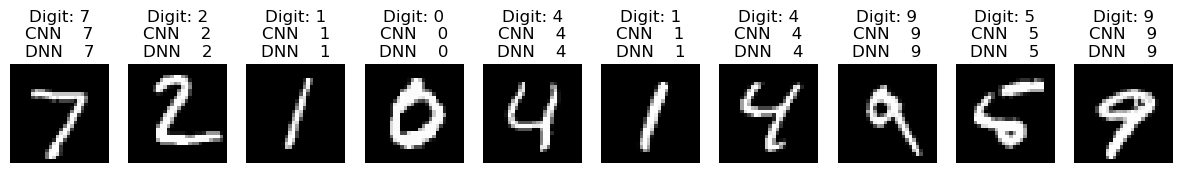

In [50]:
import matplotlib.pyplot as plt
X_train,Y_train,X_test,Y_test,input_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes,NNtype='CNN')
DNNX_train,DNNY_train,DNNX_test,DNNY_test,DNNinput_shape= utils.create_mnist_dataset(img_rows,img_cols,num_classes,NNtype='DNN')
predictions = model.predict(X_test)
DNN_pred = DNN_model.predict(DNNX_test)
plt.figure(figsize=(15, 15)) 

X_test=X_test.reshape(X_test.shape[0],img_rows,img_cols,1)
for i in range(10):    
    ax = plt.subplot(2, 10, i + 1)    
    plt.imshow(X_test[i, :, :, 0], cmap='gray')    
    plt.title("Digit: {}\nCNN    {}\nDNN    {}".format(np.argmax(Y_test[i]), np.argmax(predictions[i]),np.argmax(DNN_pred[i])))    
    plt.axis('off') 
plt.show()

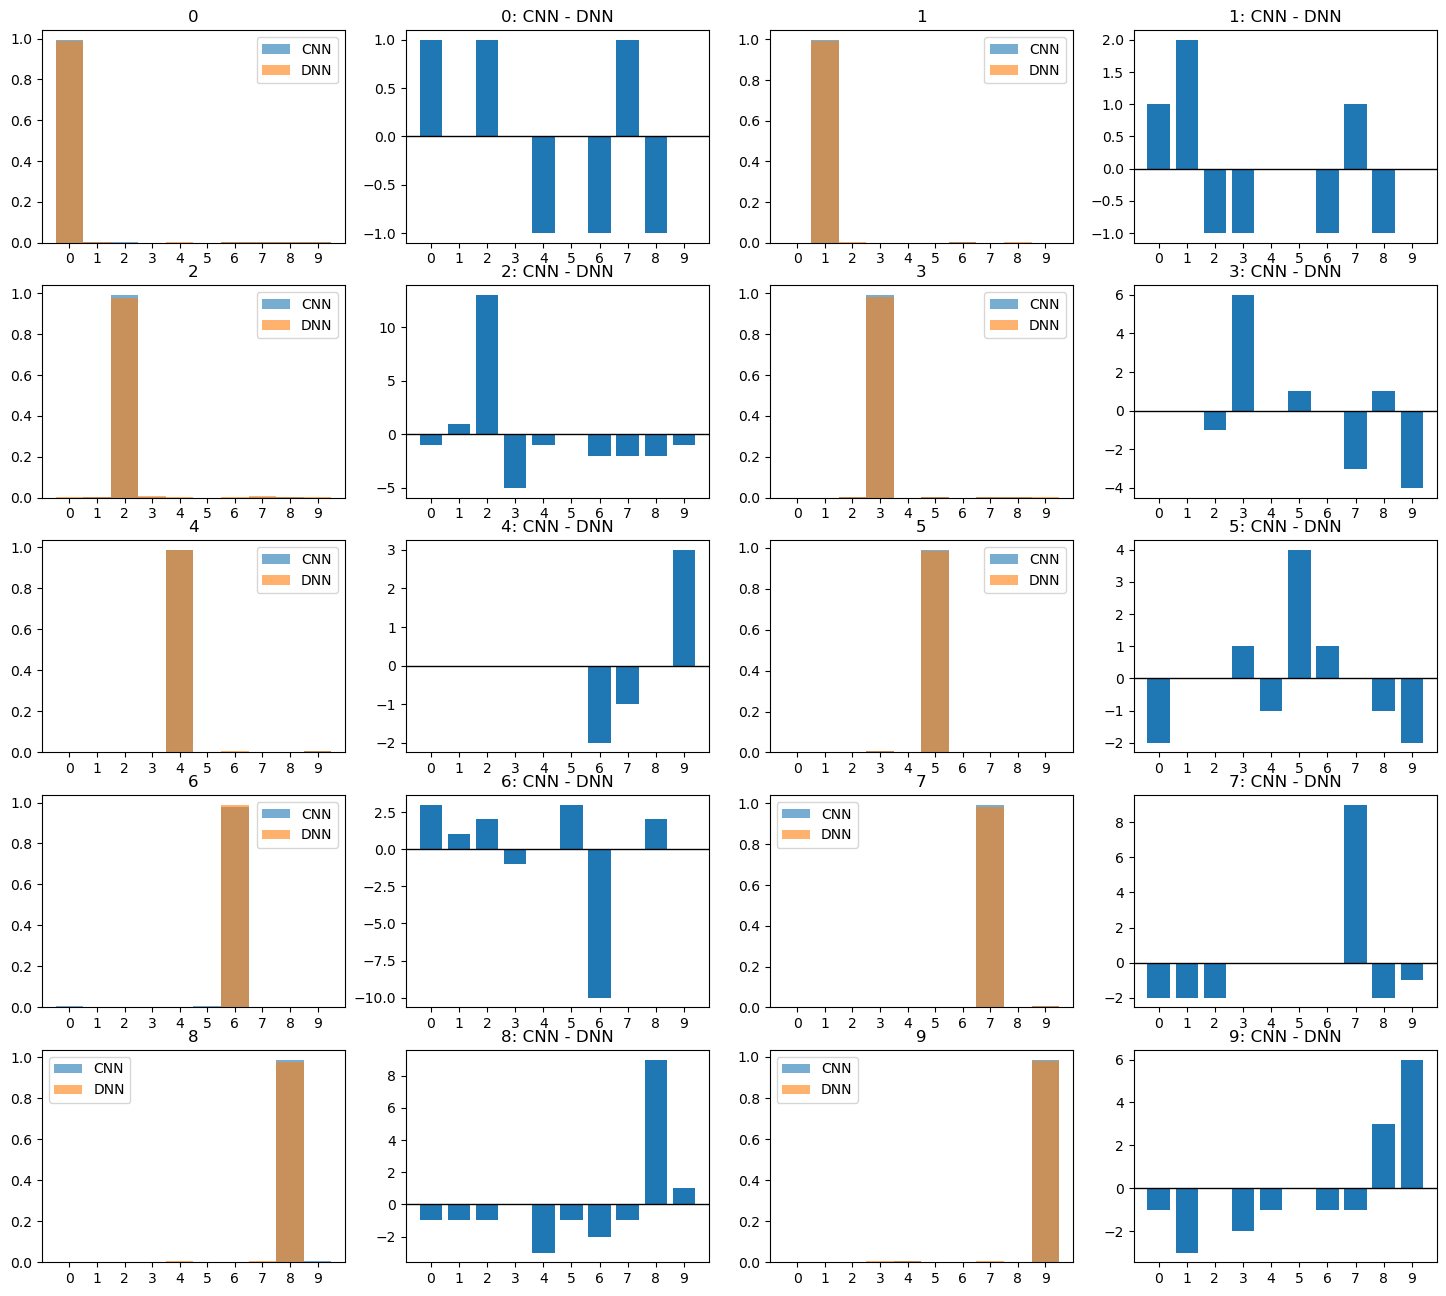

In [62]:
bins = np.linspace(-0.5, 9.5, 11)
fig, ax = plt.subplots(5, 4, figsize=(18, 16))
ax = ax.flatten()

for j in range(10):

    # Pick the axes: histogram on the left, difference on the right
    ax_hist = ax[2*j]
    ax_diff = ax[2*j + 1]

    mask = Y_test[:, j] == 1
    y_pred = np.argmax(predictions[mask], axis=1)
    DNNy_pred = np.argmax(DNN_pred[mask], axis=1)

    # --- Histogram (left plot) ---
    ax_hist.hist(y_pred, bins=bins, density=True, alpha=0.6, label="CNN")
    ax_hist.hist(DNNy_pred, bins=bins, density=True, alpha=0.6, label="DNN")
    ax_hist.set_title(j)
    ax_hist.set_xticks(range(10))
    ax_hist.legend()

    # --- Compute histogram difference ---
    hist1, _ = np.histogram(y_pred, bins=bins)
    hist2, _ = np.histogram(DNNy_pred, bins=bins)
    diff = hist1 - hist2

    # --- Difference plot (right plot) ---
    ax_diff.bar(range(10), diff, width=0.8)
    ax_diff.axhline(0, color='black', linewidth=1)
    ax_diff.set_title(f"{j}: CNN - DNN")
    ax_diff.set_xticks(range(10))


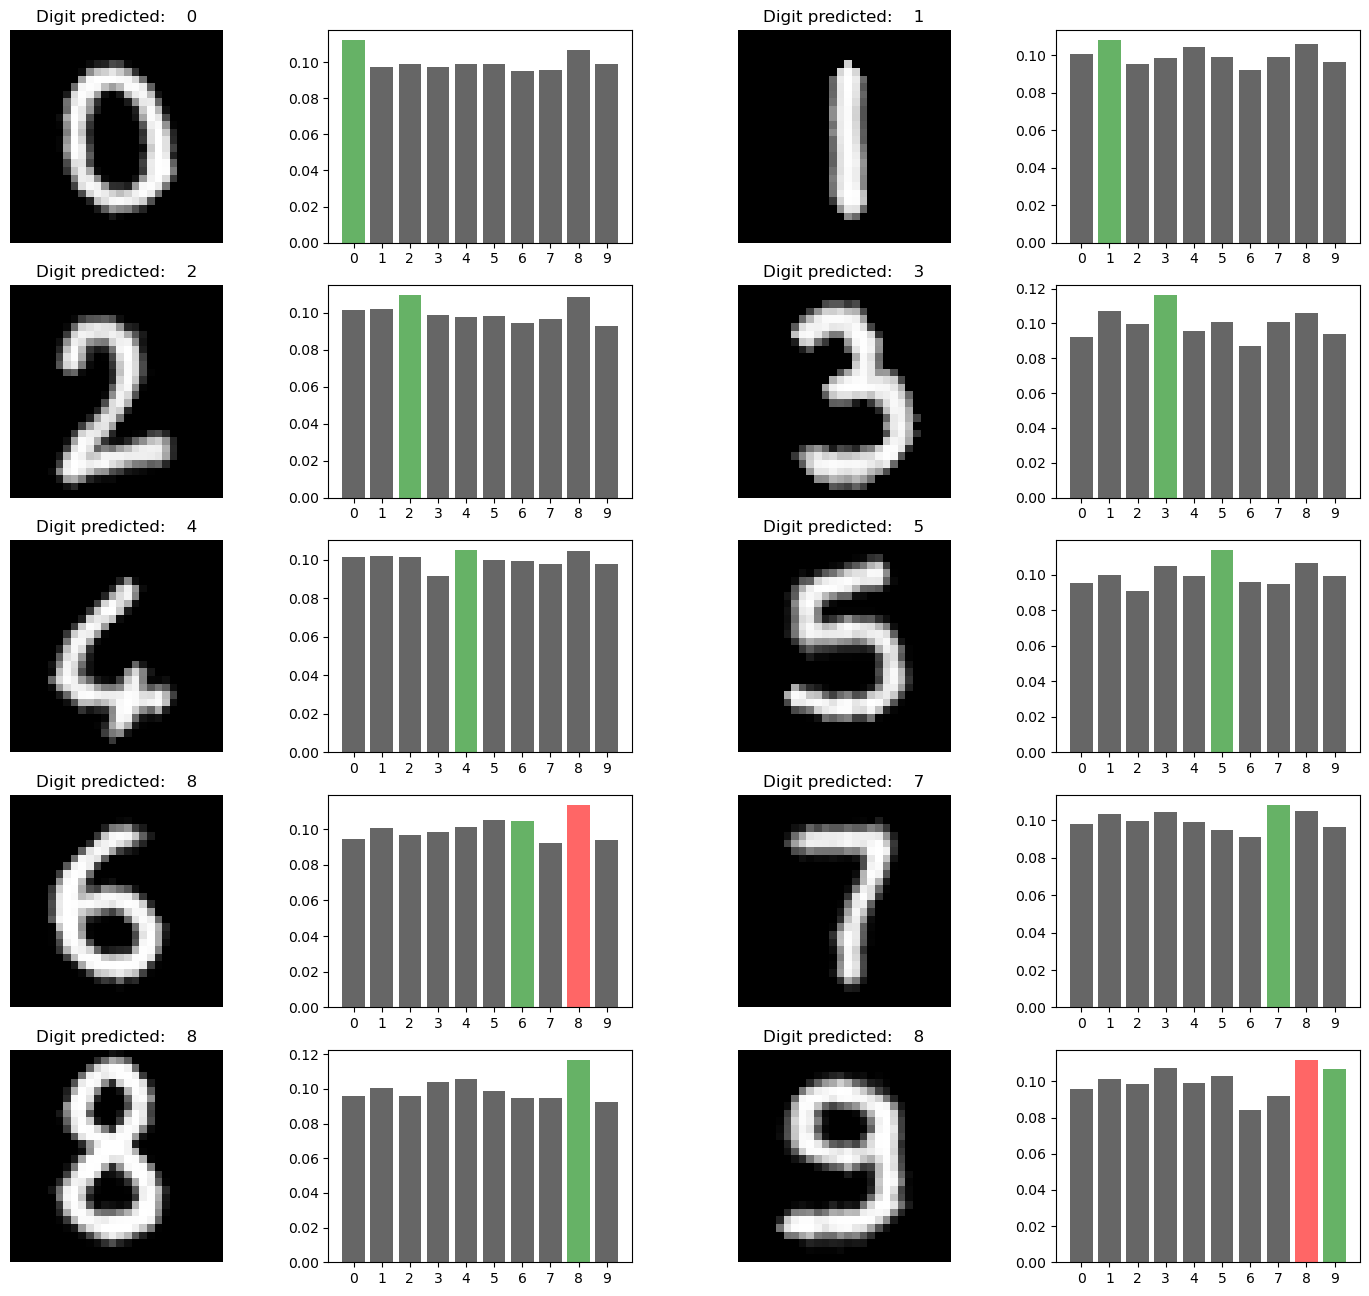

In [81]:
from PIL import Image
import os

fig, ax = plt.subplots(5, 4, figsize=(18, 16))
ax = ax.flatten()
for k in range (10):
    ax_fig = ax[2*k]
    ax_hist = ax[2*k + 1]
    digit_filename = f"./digits/{k}.png"
    digit_in = Image.open(digit_filename).convert('L')
    ydim, xdim = digit_in.size
    pix=digit_in.load();
    data = np.zeros((xdim, ydim))
    
    for j in range(ydim):
        for i in range(xdim):
            data[i,j]=pix[j,i]

    data /= 255

    data=data.reshape(1,xdim,ydim,1)

    pred= model.predict(data,verbose=0) 

    data = data.reshape(xdim,ydim)
  
    imax = np.argmax(pred[0])

# Default color for all bars
    colors = ['black'] * 10           
    colors[k] = 'green'   
    if (k==imax) : colors[imax]='green'
    else: colors[imax]='red'# highlight max


  
    ax_fig.imshow(data, cmap='gray')    
    ax_fig.set_title("Digit predicted:    {}".format(np.argmax(pred)))
    ax_fig.axis('off') 
    bins=np.linspace(0,10,10)
    
    ax_hist.bar(range(10),pred[0],color=colors,alpha=0.6)
    ax_hist.set_xticks(range(10))



(5, 5, 1, 10)


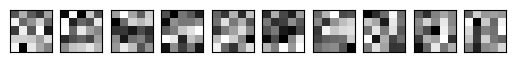

In [32]:
layer_index=0
# retrieve weights from the convolutional hidden layer
filters, biases = model.layers[layer_index].get_weights()
# normalize filter values to 0-1 so we can visualize them
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)
print(filters.shape)

# plot filters
n_filters, ix = filters.shape[3], 1
for i in range(n_filters):
    # get the filter
    f = filters[:, :, :, i]
    # specify subplot and turn of axis
    ax = plt.subplot(1,n_filters, ix)
    ax.set_xticks([])
    ax.set_yticks([])
    # plot filter channel in grayscale
    plt.imshow(f[:, :, 0], cmap='gray')
    ix += 1
# show the figure
plt.show()

DA FARE: 
- test DNN sgd vs adamax con 50 epoche
- sistemare CNN: togliere un po' di filtri